# Liver Disease Prediction — Model Training

This notebook focuses on preparing the cleaned liver disease dataset,
training machine learning models, evaluating their performance,
tuning selected models, and saving the final prediction pipeline.

## 1. Import Required Libraries

The required libraries are imported for data handling, preprocessing,
model training, evaluation, visualization, and model persistence.

In [3]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Project Paths

The cleaned liver disease dataset is loaded from the project's raw-data
directory.

The trained pipeline will later be saved in the `models` directory.

In [4]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("../../")

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "liver_disease.csv.csv"

# Correct column names from the liver disease dataset
LIVER_COLUMNS = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Proteins",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
    "Selector"
]

# Load dataset WITHOUT assuming the first row is a header
liver_df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=LIVER_COLUMNS
)

print("Dataset loaded successfully.")
print("Shape:", liver_df.shape)

print("\nColumns:")
print(liver_df.columns.tolist())

print("\nFirst 5 rows:")
display(liver_df.head())

Dataset loaded successfully.
Shape: (583, 11)

Columns:
['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Selector']

First 5 rows:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [5]:
duplicate_count = liver_df.duplicated().sum()

print("Duplicate rows before cleaning:", duplicate_count)

liver_clean_df = (
    liver_df
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Duplicate rows removed:", duplicate_count)
print("Duplicate rows after cleaning:", liver_clean_df.duplicated().sum())
print("Cleaned dataset shape:", liver_clean_df.shape)

Duplicate rows before cleaning: 13
Duplicate rows removed: 13
Duplicate rows after cleaning: 0
Cleaned dataset shape: (570, 11)


In [6]:
CLEAN_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "liver_disease_cleaned.csv"
)

liver_clean_df.to_csv(
    CLEAN_DATA_PATH,
    index=False
)

print("Corrected cleaned dataset saved successfully.")
print("Path:", CLEAN_DATA_PATH.resolve())
print("Shape:", liver_clean_df.shape)

Corrected cleaned dataset saved successfully.
Path: C:\Users\mvans\OneDrive\Desktop\Healytics\data\raw\liver_disease_cleaned.csv
Shape: (570, 11)


In [7]:
liver_df = pd.read_csv(CLEAN_DATA_PATH)

print("Cleaned liver dataset loaded successfully.")
print("Shape:", liver_df.shape)
print("\nColumns:")
print(liver_df.columns.tolist())

Cleaned liver dataset loaded successfully.
Shape: (570, 11)

Columns:
['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Selector']


## 3. Feature and Target Separation

The cleaned liver disease dataset is divided into input features (`X`)
and the target variable (`y`).

The target variable is `Selector`, where:
- 1 = Liver Disease
- 2 = No Liver Disease

In [8]:
# Target column
target_column = "Selector"

# Separate features and target
X = liver_df.drop(columns=[target_column])
y = liver_df[target_column]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget values:")
print(sorted(y.unique()))

print("\nTarget distribution:")
print(y.value_counts().sort_index())

print("\nTarget percentages:")
print(
    (y.value_counts(normalize=True).sort_index() * 100).round(2)
)

Feature shape: (570, 10)
Target shape: (570,)

Feature columns:
['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio']

Target values:
[np.int64(1), np.int64(2)]

Target distribution:
Selector
1    406
2    164
Name: count, dtype: int64

Target percentages:
Selector
1    71.23
2    28.77
Name: proportion, dtype: float64


## 4. Data Type Inspection

The feature data contains numerical and categorical variables.
We inspect their data types before preprocessing.

In [9]:
print("Feature data types:")
print(X.dtypes)

print("\nCategorical features:")
print(X.select_dtypes(include=["object"]).columns.tolist())

print("\nNumerical features:")
print(X.select_dtypes(include=["number"]).columns.tolist())

Feature data types:
Age                             int64
Gender                            str
Total_Bilirubin               float64
Direct_Bilirubin              float64
Alkaline_Phosphotase            int64
Alamine_Aminotransferase        int64
Aspartate_Aminotransferase      int64
Total_Proteins                float64
Albumin                       float64
Albumin_and_Globulin_Ratio    float64
dtype: object

Categorical features:
['Gender']

Numerical features:
['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio']


C:\Users\mvans\AppData\Local\Temp\ipykernel_11752\511463613.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.select_dtypes(include=["object"]).columns.tolist())


## 6. Missing Value Handling

The cleaned dataset contains a small number of missing values,
particularly in `Albumin_and_Globulin_Ratio`.

Missing numerical values will be handled using median imputation
inside the machine learning preprocessing pipeline.

In [10]:
missing_values = X.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": (
        missing_values / len(X) * 100
    ).round(2)
})

display(
    missing_summary[
        missing_summary["Missing Count"] > 0
    ]
)

,Missing Count,Missing Percentage
Albumin_and_Globulin_Ratio,4,0.7


## 7. Train-Test Split

The dataset is divided into training and testing sets.

A stratified split is used to preserve the proportion of the two
target classes in both sets.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

Training feature shape: (456, 10)
Testing feature shape: (114, 10)

Training target distribution:
Selector
1    325
2    131
Name: count, dtype: int64

Testing target distribution:
Selector
1    81
2    33
Name: count, dtype: int64


## 8. Feature Groups

Numerical features will be median-imputed and standardized.

Categorical features will be most-frequent imputed and one-hot encoded.

In [12]:
numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio']

Categorical features:
['Gender']


C:\Users\mvans\AppData\Local\Temp\ipykernel_11752\1302746332.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


## 9. Preprocessing Pipeline

A `ColumnTransformer` is used so that numerical and categorical
features receive appropriate preprocessing.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 10. Baseline Logistic Regression

Logistic Regression is used as the first baseline classification model.

The preprocessing pipeline handles:
- Missing numerical values
- Numerical feature scaling
- Categorical feature encoding

The model is evaluated using accuracy, precision, recall, F1-score,
and ROC-AUC.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Create Logistic Regression pipeline
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
logistic_pipeline.fit(X_train, y_train)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


## 11. Baseline Logistic Regression Evaluation

The trained Logistic Regression model is evaluated on the unseen
test dataset using multiple classification metrics.

In [15]:
# Predictions
y_pred = logistic_pipeline.predict(X_test)
y_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=2)
recall = recall_score(y_test, y_pred, pos_label=2)
f1 = f1_score(y_test, y_pred, pos_label=2)
roc_auc = roc_auc_score(
    (y_test == 2).astype(int),
    y_proba
)

print("BASELINE LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Class 1", "Class 2"]
    )
)

BASELINE LOGISTIC REGRESSION
Accuracy : 0.7544
Precision: 0.6923
Recall   : 0.2727
F1-Score : 0.3913
ROC-AUC  : 0.7890

Classification Report:
              precision    recall  f1-score   support

     Class 1       0.76      0.95      0.85        81
     Class 2       0.69      0.27      0.39        33

    accuracy                           0.75       114
   macro avg       0.73      0.61      0.62       114
weighted avg       0.74      0.75      0.71       114



## 12. Baseline Random Forest

Random Forest is trained as the second baseline classification model.

It can capture nonlinear relationships between liver-disease-related
features that Logistic Regression may not capture.

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train the model
random_forest_pipeline.fit(X_train, y_train)

print("Baseline Random Forest trained successfully.")

Baseline Random Forest trained successfully.


In [17]:
# Predictions
y_pred_rf = random_forest_pipeline.predict(X_test)
y_proba_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

# Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label=2)
recall_rf = recall_score(y_test, y_pred_rf, pos_label=2)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=2)

roc_auc_rf = roc_auc_score(
    (y_test == 2).astype(int),
    y_proba_rf
)

print("BASELINE RANDOM FOREST")
print("=" * 50)
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Class 1", "Class 2"]
    )
)

BASELINE RANDOM FOREST
Accuracy : 0.6579
Precision: 0.3636
Recall   : 0.2424
F1-Score : 0.2909
ROC-AUC  : 0.7245

Classification Report:
              precision    recall  f1-score   support

     Class 1       0.73      0.83      0.77        81
     Class 2       0.36      0.24      0.29        33

    accuracy                           0.66       114
   macro avg       0.55      0.53      0.53       114
weighted avg       0.62      0.66      0.63       114



## 14. Baseline Gradient Boosting

Gradient Boosting is trained as the third baseline classification model.

The model builds an ensemble of sequential decision trees and can
capture nonlinear relationships between the input features.

In [18]:
from sklearn.ensemble import GradientBoostingClassifier

# Create Gradient Boosting pipeline
gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# Train the model
gradient_boosting_pipeline.fit(X_train, y_train)

print("Baseline Gradient Boosting trained successfully.")

Baseline Gradient Boosting trained successfully.


In [19]:
# Predictions
y_pred_gb = gradient_boosting_pipeline.predict(X_test)
y_proba_gb = gradient_boosting_pipeline.predict_proba(X_test)[:, 1]

# Metrics
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, pos_label=2)
recall_gb = recall_score(y_test, y_pred_gb, pos_label=2)
f1_gb = f1_score(y_test, y_pred_gb, pos_label=2)

roc_auc_gb = roc_auc_score(
    (y_test == 2).astype(int),
    y_proba_gb
)

print("BASELINE GRADIENT BOOSTING")
print("=" * 50)
print(f"Accuracy : {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall   : {recall_gb:.4f}")
print(f"F1-Score : {f1_gb:.4f}")
print(f"ROC-AUC  : {roc_auc_gb:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_gb,
        target_names=["Class 1", "Class 2"]
    )
)

BASELINE GRADIENT BOOSTING
Accuracy : 0.6579
Precision: 0.4062
Recall   : 0.3939
F1-Score : 0.4000
ROC-AUC  : 0.7048

Classification Report:
              precision    recall  f1-score   support

     Class 1       0.76      0.77      0.76        81
     Class 2       0.41      0.39      0.40        33

    accuracy                           0.66       114
   macro avg       0.58      0.58      0.58       114
weighted avg       0.65      0.66      0.66       114



## 16. Baseline Model Comparison

The three baseline models are compared using accuracy, precision,
recall, F1-score, and ROC-AUC on the same test dataset.

In [20]:
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf,
        accuracy_gb
    ],
    "Precision": [
        precision,
        precision_rf,
        precision_gb
    ],
    "Recall": [
        recall,
        recall_rf,
        recall_gb
    ],
    "F1-Score": [
        f1,
        f1_rf,
        f1_gb
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_rf,
        roc_auc_gb
    ]
})

print("BASELINE MODEL COMPARISON")
print("=" * 70)

display(
    baseline_results.round(4)
)

BASELINE MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7544,0.6923,0.2727,0.3913,0.7890
1,Random Forest,0.6579,0.3636,0.2424,0.2909,0.7245
2,Gradient Boosting,0.6579,0.4062,0.3939,0.4000,0.7048


In [21]:
baseline_results.to_csv(
    "liver_baseline_results.csv",
    index=False
)

print("Baseline results saved successfully.")

Baseline results saved successfully.


## 18. Hyperparameter Tuning — Logistic Regression

Grid Search with cross-validation is used to identify suitable
Logistic Regression hyperparameters.

ROC-AUC is used as the optimization metric.

In [22]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression pipeline for tuning
logistic_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Hyperparameter grid
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

# Grid Search
logistic_grid_search = GridSearchCV(
    estimator=logistic_tuning_pipeline,
    param_grid=logistic_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

# Fit
logistic_grid_search.fit(X_train, y_train)

print("Best parameters:")
print(logistic_grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(f"{logistic_grid_search.best_score_:.4f}")

Best parameters:
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Best cross-validation ROC-AUC:
0.7213


c:\Users\mvans\OneDrive\Desktop\Healytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


## 19. Tuned Logistic Regression Evaluation

The best Logistic Regression configuration identified through 5-fold
cross-validation is evaluated on the held-out test dataset.

In [23]:
# Best tuned Logistic Regression model
tuned_logistic_pipeline = logistic_grid_search.best_estimator_

# Test predictions
y_pred_tuned_lr = tuned_logistic_pipeline.predict(X_test)
y_proba_tuned_lr = tuned_logistic_pipeline.predict_proba(X_test)[:, 1]

# Evaluation metrics
tuned_lr_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_lr
)

tuned_lr_precision = precision_score(
    y_test,
    y_pred_tuned_lr,
    pos_label=2
)

tuned_lr_recall = recall_score(
    y_test,
    y_pred_tuned_lr,
    pos_label=2
)

tuned_lr_f1 = f1_score(
    y_test,
    y_pred_tuned_lr,
    pos_label=2
)

tuned_lr_roc_auc = roc_auc_score(
    (y_test == 2).astype(int),
    y_proba_tuned_lr
)

print("TUNED LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy : {tuned_lr_accuracy:.4f}")
print(f"Precision: {tuned_lr_precision:.4f}")
print(f"Recall   : {tuned_lr_recall:.4f}")
print(f"F1-Score : {tuned_lr_f1:.4f}")
print(f"ROC-AUC  : {tuned_lr_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned_lr,
        target_names=["Class 1", "Class 2"]
    )
)

TUNED LOGISTIC REGRESSION
Accuracy : 0.7193
Precision: 0.5556
Recall   : 0.1515
F1-Score : 0.2381
ROC-AUC  : 0.8010

Classification Report:
              precision    recall  f1-score   support

     Class 1       0.73      0.95      0.83        81
     Class 2       0.56      0.15      0.24        33

    accuracy                           0.72       114
   macro avg       0.64      0.55      0.53       114
weighted avg       0.68      0.72      0.66       114



## 20. Hyperparameter Tuning — Random Forest

Grid Search with 5-fold cross-validation is used to identify a suitable
Random Forest configuration.

ROC-AUC is used as the optimization metric.

In [24]:
# Random Forest pipeline for tuning
random_forest_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

# Hyperparameter grid
random_forest_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# Grid Search
random_forest_grid_search = GridSearchCV(
    estimator=random_forest_tuning_pipeline,
    param_grid=random_forest_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

# Fit
random_forest_grid_search.fit(X_train, y_train)

print("Best parameters:")
print(random_forest_grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(f"{random_forest_grid_search.best_score_:.4f}")

Best parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 50}

Best cross-validation ROC-AUC:
0.7074


## 21. Tuned Random Forest Evaluation

The best Random Forest configuration identified through 5-fold
cross-validation is evaluated on the held-out test dataset.

In [25]:
# Best tuned Random Forest model
tuned_random_forest_pipeline = (
    random_forest_grid_search.best_estimator_
)

# Test predictions
y_pred_tuned_rf = tuned_random_forest_pipeline.predict(X_test)
y_proba_tuned_rf = (
    tuned_random_forest_pipeline.predict_proba(X_test)[:, 1]
)

# Evaluation metrics
tuned_rf_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_rf
)

tuned_rf_precision = precision_score(
    y_test,
    y_pred_tuned_rf,
    pos_label=2
)

tuned_rf_recall = recall_score(
    y_test,
    y_pred_tuned_rf,
    pos_label=2
)

tuned_rf_f1 = f1_score(
    y_test,
    y_pred_tuned_rf,
    pos_label=2
)

tuned_rf_roc_auc = roc_auc_score(
    (y_test == 2).astype(int),
    y_proba_tuned_rf
)

print("TUNED RANDOM FOREST")
print("=" * 50)
print(f"Accuracy : {tuned_rf_accuracy:.4f}")
print(f"Precision: {tuned_rf_precision:.4f}")
print(f"Recall   : {tuned_rf_recall:.4f}")
print(f"F1-Score : {tuned_rf_f1:.4f}")
print(f"ROC-AUC  : {tuned_rf_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned_rf,
        target_names=["Class 1", "Class 2"]
    )
)

TUNED RANDOM FOREST
Accuracy : 0.7281
Precision: 0.5714
Recall   : 0.2424
F1-Score : 0.3404
ROC-AUC  : 0.7673

Classification Report:
              precision    recall  f1-score   support

     Class 1       0.75      0.93      0.83        81
     Class 2       0.57      0.24      0.34        33

    accuracy                           0.73       114
   macro avg       0.66      0.58      0.58       114
weighted avg       0.70      0.73      0.69       114



## 22. Hyperparameter Tuning — Gradient Boosting

Grid Search with 5-fold cross-validation is used to identify a suitable
Gradient Boosting configuration.

ROC-AUC is used as the optimization metric.

In [26]:
# Gradient Boosting pipeline for tuning
gradient_boosting_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

# Hyperparameter grid
gradient_boosting_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__min_samples_split": [2, 5]
}

# Grid Search
gradient_boosting_grid_search = GridSearchCV(
    estimator=gradient_boosting_tuning_pipeline,
    param_grid=gradient_boosting_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

# Fit
gradient_boosting_grid_search.fit(X_train, y_train)

print("Best parameters:")
print(gradient_boosting_grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(f"{gradient_boosting_grid_search.best_score_:.4f}")

Best parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best cross-validation ROC-AUC:
0.7022


## 23. Tuned Gradient Boosting Evaluation

The best Gradient Boosting configuration identified through 5-fold
cross-validation is evaluated on the held-out test dataset.

In [27]:
# Best tuned Gradient Boosting model
tuned_gradient_boosting_pipeline = (
    gradient_boosting_grid_search.best_estimator_
)

# Test predictions
y_pred_tuned_gb = (
    tuned_gradient_boosting_pipeline.predict(X_test)
)

y_proba_tuned_gb = (
    tuned_gradient_boosting_pipeline.predict_proba(X_test)[:, 1]
)

# Evaluation metrics
tuned_gb_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_gb
)

tuned_gb_precision = precision_score(
    y_test,
    y_pred_tuned_gb,
    pos_label=2
)

tuned_gb_recall = recall_score(
    y_test,
    y_pred_tuned_gb,
    pos_label=2
)

tuned_gb_f1 = f1_score(
    y_test,
    y_pred_tuned_gb,
    pos_label=2
)

tuned_gb_roc_auc = roc_auc_score(
    (y_test == 2).astype(int),
    y_proba_tuned_gb
)

print("TUNED GRADIENT BOOSTING")
print("=" * 50)
print(f"Accuracy : {tuned_gb_accuracy:.4f}")
print(f"Precision: {tuned_gb_precision:.4f}")
print(f"Recall   : {tuned_gb_recall:.4f}")
print(f"F1-Score : {tuned_gb_f1:.4f}")
print(f"ROC-AUC  : {tuned_gb_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned_gb,
        target_names=["Class 1", "Class 2"]
    )
)

TUNED GRADIENT BOOSTING
Accuracy : 0.7193
Precision: 0.5294
Recall   : 0.2727
F1-Score : 0.3600
ROC-AUC  : 0.7563

Classification Report:
              precision    recall  f1-score   support

     Class 1       0.75      0.90      0.82        81
     Class 2       0.53      0.27      0.36        33

    accuracy                           0.72       114
   macro avg       0.64      0.59      0.59       114
weighted avg       0.69      0.72      0.69       114



## 24. Tuned Model Comparison

The tuned Logistic Regression, Random Forest, and Gradient Boosting
models are compared using the same held-out test dataset.

In [28]:
tuned_results = pd.DataFrame({
    "Model": [
        "Tuned Logistic Regression",
        "Tuned Random Forest",
        "Tuned Gradient Boosting"
    ],
    "Accuracy": [
        tuned_lr_accuracy,
        tuned_rf_accuracy,
        tuned_gb_accuracy
    ],
    "Precision": [
        tuned_lr_precision,
        tuned_rf_precision,
        tuned_gb_precision
    ],
    "Recall": [
        tuned_lr_recall,
        tuned_rf_recall,
        tuned_gb_recall
    ],
    "F1-Score": [
        tuned_lr_f1,
        tuned_rf_f1,
        tuned_gb_f1
    ],
    "ROC-AUC": [
        tuned_lr_roc_auc,
        tuned_rf_roc_auc,
        tuned_gb_roc_auc
    ]
})

print("TUNED MODEL COMPARISON")
print("=" * 70)

display(tuned_results.round(4))

TUNED MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Logistic Regression,0.7193,0.5556,0.1515,0.2381,0.8010
1,Tuned Random Forest,0.7281,0.5714,0.2424,0.3404,0.7673
2,Tuned Gradient Boosting,0.7193,0.5294,0.2727,0.3600,0.7563


In [29]:
tuned_results.to_csv(
    "liver_tuned_results.csv",
    index=False
)

print("Tuned model results saved successfully.")

Tuned model results saved successfully.


## 25. ROC-AUC Curve Comparison

ROC curves are plotted for the three tuned models to compare their
ability to distinguish between the two liver disease classes across
different classification thresholds.

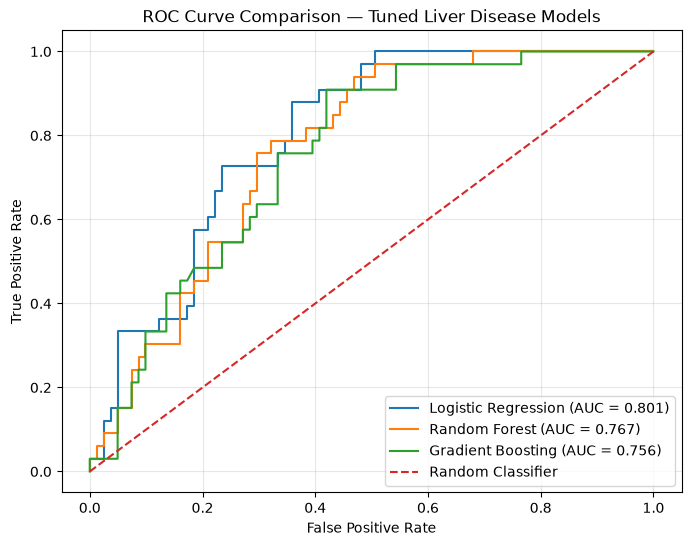

In [30]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Convert target to binary:
# Class 2 = positive class
y_test_binary = (y_test == 2).astype(int)

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(
    y_test_binary,
    y_proba_tuned_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test_binary,
    y_proba_tuned_rf
)

fpr_gb, tpr_gb, _ = roc_curve(
    y_test_binary,
    y_proba_tuned_gb
)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {tuned_lr_roc_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {tuned_rf_roc_auc:.3f})"
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting (AUC = {tuned_gb_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Tuned Liver Disease Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 26. Probability Calibration — Brier Score

The Brier score evaluates the accuracy of predicted probabilities.
Lower Brier scores indicate better-calibrated probability estimates.

In [31]:
from sklearn.metrics import brier_score_loss

# Binary true labels: Class 2 = 1, Class 1 = 0
y_test_binary = (y_test == 2).astype(int)

# Brier scores
brier_lr = brier_score_loss(
    y_test_binary,
    y_proba_tuned_lr
)

brier_rf = brier_score_loss(
    y_test_binary,
    y_proba_tuned_rf
)

brier_gb = brier_score_loss(
    y_test_binary,
    y_proba_tuned_gb
)

print("BRIER SCORES")
print("=" * 50)
print(f"Tuned Logistic Regression: {brier_lr:.4f}")
print(f"Tuned Random Forest:       {brier_rf:.4f}")
print(f"Tuned Gradient Boosting:   {brier_gb:.4f}")

BRIER SCORES
Tuned Logistic Regression: 0.1652
Tuned Random Forest:       0.1675
Tuned Gradient Boosting:   0.1721


## 27. Final Model Comparison

The tuned models are compared using discrimination performance
(ROC-AUC), probability calibration (Brier Score), and classification
metrics on the held-out test set.

In [32]:
final_model_comparison = tuned_results.copy()

final_model_comparison["Brier Score"] = [
    brier_lr,
    brier_rf,
    brier_gb
]

print("FINAL MODEL COMPARISON")
print("=" * 85)

display(
    final_model_comparison.round(4)
)

# Save final comparison
final_model_comparison.to_csv(
    "liver_final_model_comparison.csv",
    index=False
)

print("\nFinal comparison saved successfully.")

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Brier Score
0,Tuned Logistic Regression,0.7193,0.5556,0.1515,0.2381,0.8010,0.1652
1,Tuned Random Forest,0.7281,0.5714,0.2424,0.3404,0.7673,0.1675
2,Tuned Gradient Boosting,0.7193,0.5294,0.2727,0.3600,0.7563,0.1721



Final comparison saved successfully.


## 28. Final Liver Disease Model

The tuned Logistic Regression pipeline is selected as the final
liver disease prediction model based on its test-set ROC-AUC and
Brier Score.

The model's relatively low Class 2 recall is documented as a
limitation and should be considered when interpreting predictions.

## 29. Save Final Liver Disease Pipeline

The selected tuned Logistic Regression pipeline is saved for
deployment in the Healytics application.

The preprocessing steps and trained model are stored together
to ensure that application inputs receive the same transformations
used during model training.

In [33]:
import joblib
from pathlib import Path

# Create models directory if it does not exist
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Path for final liver model
LIVER_MODEL_PATH = MODELS_DIR / "liver_disease_pipeline.joblib"

# Save the evaluated tuned pipeline
joblib.dump(
    tuned_logistic_pipeline,
    LIVER_MODEL_PATH
)

print("Final liver disease pipeline saved successfully.")
print("Path:", LIVER_MODEL_PATH.resolve())

Final liver disease pipeline saved successfully.
Path: C:\Users\mvans\OneDrive\Desktop\Healytics\models\liver_disease_pipeline.joblib


In [34]:
print("File exists:", LIVER_MODEL_PATH.exists())
print("File size:", round(LIVER_MODEL_PATH.stat().st_size / 1024, 2), "KB")

File exists: True
File size: 4.68 KB


In [35]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: c:\Users\mvans\OneDrive\Desktop\Healytics\notebooks
src exists: False


In [36]:
print("Current working directory:")
print(Path.cwd())

print("\nParent:")
print(Path.cwd().parent)

print("\nParent of parent:")
print(Path.cwd().parent.parent)

Current working directory:
c:\Users\mvans\OneDrive\Desktop\Healytics\notebooks\liver

Parent:
c:\Users\mvans\OneDrive\Desktop\Healytics\notebooks

Parent of parent:
c:\Users\mvans\OneDrive\Desktop\Healytics


In [37]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())
print("model exists:", (PROJECT_ROOT / "models" / "liver_disease_pipeline.joblib").exists())

Project root: c:\Users\mvans\OneDrive\Desktop\Healytics
src exists: True
model exists: True


In [38]:
from src.prediction.liver_disease_predictor import predict_liver_disease

In [39]:
result = predict_liver_disease(
    age=45,
    gender="Male",
    total_bilirubin=1.0,
    direct_bilirubin=0.3,
    alkaline_phosphotase=200,
    alamine_aminotransferase=35,
    aspartate_aminotransferase=40,
    total_proteins=6.5,
    albumin=3.2,
    albumin_and_globulin_ratio=0.9
)

print(result)

{'prediction': 1, 'result': 'Liver Disease', 'risk_probability': 0.6283253987027397}


In [40]:
print("Selector 1 examples:")
display(liver_clean_df[liver_clean_df["Selector"] == 1].head())

print("\nSelector 2 examples:")
display(liver_clean_df[liver_clean_df["Selector"] == 2].head())

Selector 1 examples:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1



Selector 2 examples:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Selector
8,17,Male,0.9,0.3,202,22,19,7.4,4.1,1.20,2
12,64,Male,0.9,0.3,310,61,58,7.0,3.4,0.90,2
15,25,Male,0.6,0.1,183,91,53,5.5,2.3,0.70,2
17,33,Male,1.6,0.5,165,15,23,7.3,3.5,0.92,2
23,63,Male,0.9,0.2,194,52,45,6.0,3.9,1.85,2


In [41]:
print(y_train.unique())
print(y_test.unique())

[1 2]
[1 2]


In [42]:
import joblib
from sklearn.metrics import accuracy_score, classification_report

# Load trained liver pipeline
liver_model = joblib.load("../../models/liver_disease_pipeline.joblib")

# Prediction
y_pred = liver_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print("LIVER DISEASE MODEL TEST RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Accuracy : {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


LIVER DISEASE MODEL TEST RESULTS
Accuracy : 0.7193
Accuracy : 71.93%

Classification Report:
              precision    recall  f1-score   support

           1       0.73      0.95      0.83        81
           2       0.56      0.15      0.24        33

    accuracy                           0.72       114
   macro avg       0.64      0.55      0.53       114
weighted avg       0.68      0.72      0.66       114



In [62]:
print(liver_clean_df.columns)

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Selector'],
      dtype='str')


In [63]:
print(liver_clean_df.iloc[:, -1].value_counts().sort_index())

Selector
1    406
2    164
Name: count, dtype: int64
